In [ ]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs
from matplotlib import pyplot as plt

In [2]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')

In [3]:
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'

In [4]:
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'

In [5]:
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'

In [6]:
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)

In [7]:
df_important_TF.columns=['TF']

In [8]:
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_3807734/313275177.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [9]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [10]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [11]:
outdir

'/data2st1/junyi/scenic/mouse/motif/merged_cluster'

In [12]:
df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)

In [13]:
df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']

/tmp/ipykernel_3807734/605102179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']


In [14]:
df_direct_annot

,MotifID,motif_name,motif_description,source_name,source_version,TF,MotifSimilarityQvalue,similar_motif_id,similar_motif_description,OrthologousIdentity,orthologous_gene_name,orthologous_species,Annotation,soure_name
183,c2h2_zfs__M0369,M0369,ENSMUSG00000000317,c2h2_zfs,0.90,Bcl6b,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0369
184,c2h2_zfs__M0373,M0373,ENSMUSG00000022228,c2h2_zfs,0.90,Zscan26,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0373
185,c2h2_zfs__M0385,M0385,ENSMUSG00000028890,c2h2_zfs,0.90,Mtf1,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0385
186,c2h2_zfs__M0393,M0393,ENSMUSG00000033863,c2h2_zfs,0.90,Klf9,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0393
189,c2h2_zfs__M0400,M0400,ENSMUSG00000041703,c2h2_zfs,0.90,Zic5,0.0,None,None,1.0,None,None,gene is directly annotated,c2h2_zfs__M0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251819,transfac_public__M00532,M00532,V$RP58_01: RP58,transfac_public,7.0,Zbtb18,0.0,None,None,1.0,None,None,gene is directly annotated,transfac_public__M00532
251825,metacluster_71.11,M00538,V$HTF_01: HTF (XBP1),transfac_public,7.0,Xbp1,0.0,None,None,1.0,None,None,gene is directly annotated,transfac_public__M00538
251826,metacluster_57.3,M00539,V$ARNT_02: Arnt,transfac_public,7.0,Arnt,0.0,None,None,1.0,None,None,gene is directly annotated,transfac_public__M00539
251904,metacluster_198.2,M00615,V$MYCMAX_03: c-Myc:Max,transfac_public,7.0,Max,0.0,None,None,1.0,None,None,gene is directly annotated,transfac_public__M00615


In [15]:
dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))

In [16]:
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [17]:
direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]

In [18]:
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


In [19]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

In [20]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [21]:
TOBIAS_Rsults = glob.glob(f'/data2st2/junyi/output/atac1112/tobiasbam/*/*.bw/bindetect_results.xlsx')

In [22]:
%%capture
# ignore cell outputs for this cell
results = pd.DataFrame()
full = pd.DataFrame()
full_results = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = df_tobias['name'].str.split('#').str[1]
    df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()
    df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)
    # df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    # df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)
    df_expanded = df_tobias.copy()
    df_expanded['TFexpand'] = df_expanded['TF']

    # df_expanded
    df_expanded_mean = df_expanded.groupby('TFexpand').mean()
    df_expanded_mean['TF'] = df_expanded_mean.index
    df_expanded_mean['ctname'] = ctname
    df_expanded_mean['Region'] = region

    full_results = pd.concat([full_results, df_tobias], axis=0)
    results = pd.concat([results, df_expanded_mean], axis=0)

In [24]:
def add_columns(results):
    results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    results['log2FC'] = results['MC_MW_change']
    results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results

In [25]:
full_results = add_columns(full_results)
avg_results = add_columns(results)

In [26]:
full_results[full_results.FDR < 0.05]

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Sex,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,Region,status,celltype.L2
1559,metacluster_157.2homer__RATGASTCAT_JunB_None,metacluster_157.2#homer__RATGASTCAT_JunB,None,C_metacluster_50.1#transfac_public__M00038,7290,2.28474,1569,3.16458,2330,-0.25633,...,M,Junb,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25633,5.007000e-132,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
2689,metacluster_137.2homer__GGATGACTCATC_Fra2_None,metacluster_137.2#homer__GGATGACTCATC_Fra2,None,C_metacluster_50.1#transfac_public__M00038,7559,2.30070,1643,3.16800,2420,-0.25220,...,M,Fosl2,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25220,3.431600e-135,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
2521,metacluster_50.1homer__NDATGASTCAYN_Fos_None,metacluster_50.1#homer__NDATGASTCAYN_Fos,None,C_metacluster_50.1#transfac_public__M00038,7492,2.22564,1553,3.07302,2283,-0.25169,...,M,Fos,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25169,2.404770e-130,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
2685,metacluster_137.2homer__ATGACTCATC_AP-1_None,metacluster_137.2#homer__ATGACTCATC_AP-1,None,C_metacluster_50.1#transfac_public__M00038,7562,2.30559,1645,3.17551,2422,-0.25143,...,M,Jun,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25143,6.015440e-134,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
2520,metacluster_50.1homer__NATGASTCABNN_Fosl2_None,metacluster_50.1#homer__NATGASTCABNN_Fosl2,None,C_metacluster_50.1#transfac_public__M00038,7367,2.28692,1581,3.15783,2343,-0.25110,...,M,Fosl2,GABA,PFC_PFC_Sst_Chodl_GABA,-0.25110,2.395590e-134,PFC_Sst_Chodl_GABA,PFC,Down,PFC_Sst_Chodl_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2911,metacluster_43.2jaspar__MA1618.1_None,metacluster_43.2#jaspar__MA1618.1,None,C_metacluster_193.2#homer__SMCATCTGKH_TCF4,23928,0.43427,6165,0.44990,6691,-0.00147,...,M,Ptf1a,NN,AMY_MOL-2,-0.00147,3.893220e-02,MOL-2,AMY,Down,MOL-2
1845,metacluster_189.2jaspar__MA0768.2_None,metacluster_189.2#jaspar__MA0768.2,None,C_metacluster_189.2#jaspar__MA0768.2,21680,0.37745,4587,0.39490,4908,0.00142,...,M,Lef1,NN,AMY_MOL-2,0.00142,6.263540e-03,MOL-2,AMY,Up,MOL-2
4036,metacluster_165.10homer__TGATKGATGR_HOXA1_None,metacluster_165.10#homer__TGATKGATGR_HOXA1,None,C_metacluster_165.10#swissregulon__hs__HOXA2,12078,0.36641,2505,0.38178,2688,-0.00138,...,M,Hoxa1,NN,AMY_MOL-2,-0.00138,8.677550e-03,MOL-2,AMY,Down,MOL-2
4131,metacluster_18.3hocomoco__NFIC_MOUSE.H11MO.1.A...,metacluster_18.3#hocomoco__NFIC_MOUSE.H11MO.1.A,None,C_metacluster_18.2#hocomoco__NFIC_HUMAN.H11MO.0.A,38994,0.62448,14108,0.64409,14977,0.00135,...,M,Nfic,NN,AMY_MOL-2,0.00135,1.807780e-03,MOL-2,AMY,Up,MOL-2


In [27]:
full_results_filtered = full_results[full_results['MC_MW_highlighted']==True]
full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_results_filtered.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

/tmp/ipykernel_3807734/1742268152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
/tmp/ipykernel_3807734/1742268152.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
/tmp/ipykernel_3807734/1742268152.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/us

In [28]:
full_results_filtered

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Gene,Neurotransmitter,Region Subclass,log2FC,FDR,Subclass,Region,status,celltype.L2,absLog2FC
2521,metacluster_50.1homer__NDATGASTCAYN_Fos_None,metacluster_50.1#homer__NDATGASTCAYN_Fos,None,C_metacluster_50.1#transfac_public__M00038,46234,0.13832,9866,0.16497,12193,-0.48882,...,Fos,Glut,PFC_PFC_L4-5_IT_Glut,-0.48882,1.068120e-206,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.48882
2689,metacluster_137.2homer__GGATGACTCATC_Fra2_None,metacluster_137.2#homer__GGATGACTCATC_Fra2,None,C_metacluster_50.1#transfac_public__M00038,46862,0.14100,10206,0.16699,12494,-0.46652,...,Fosl2,Glut,PFC_PFC_L4-5_IT_Glut,-0.46652,4.103690e-201,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.46652
1554,metacluster_157.2dbtfbs__mm_FOSL1_C2C12_ENCSR0...,metacluster_157.2#dbtfbs__mm_FOSL1_C2C12_ENCSR...,None,C_metacluster_50.1#transfac_public__M00038,47909,0.13894,10265,0.16424,12530,-0.45869,...,Fosl1,Glut,PFC_PFC_L4-5_IT_Glut,-0.45869,7.784100e-203,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45869
1559,metacluster_157.2homer__RATGASTCAT_JunB_None,metacluster_157.2#homer__RATGASTCAT_JunB,None,C_metacluster_50.1#transfac_public__M00038,45477,0.14093,9849,0.16635,12027,-0.45288,...,Junb,Glut,PFC_PFC_L4-5_IT_Glut,-0.45288,1.249460e-199,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45288
2685,metacluster_137.2homer__ATGACTCATC_AP-1_None,metacluster_137.2#homer__ATGACTCATC_AP-1,None,C_metacluster_50.1#transfac_public__M00038,48755,0.14066,10542,0.16567,12876,-0.45049,...,Jun,Glut,PFC_PFC_L4-5_IT_Glut,-0.45049,5.300370e-198,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1421,metacluster_24.2c2h2_zfs__M5280_None,metacluster_24.2#c2h2_zfs__M5280,None,C_metacluster_24.2#c2h2_zfs__M5280,99468,0.68294,24241,0.66356,24226,0.01453,...,Bcl6,Glut,HPF_HPF_Subiculum_SUB_Glut,0.01453,8.568930e-66,HPF_Subiculum_SUB_Glut,HPF,Up,HPF_Subiculum_SUB_Glut,0.01453
3059,metacluster_6.2jaspar__MA0874.1_None,metacluster_6.2#jaspar__MA0874.1,None,C_metacluster_6.2#swissregulon__mm__Esx1,10440,0.16036,4668,0.16015,4782,0.01436,...,Arx,NN,AMY_OPC,0.01436,9.752360e-32,OPC,AMY,Up,OPC,0.01436
2455,metacluster_164.1swissregulon__mm__Meox1_None,metacluster_164.1#swissregulon__mm__Meox1,None,C_metacluster_164.1#swissregulon__mm__Meox1,12145,0.15987,5663,0.15987,5844,0.01432,...,Meox1,NN,AMY_OPC,0.01432,8.085400e-34,OPC,AMY,Up,OPC,0.01432
1136,metacluster_163.1hocomoco__KLF5_MOUSE.H11MO.0....,metacluster_163.1#hocomoco__KLF5_MOUSE.H11MO.0.A,None,C_metacluster_3.7#kznf__SP1_HocoMoco.2_Misc,60800,1.41336,25226,1.47397,26730,0.01423,...,Klf5,NN,HPF_MFOL,0.01423,3.408150e-55,MFOL,HPF,Up,MFOL,0.01423


In [39]:
df_regions = pd.DataFrame()
valid_files = []
unvalid_files = []
for idx, row in full_results_filtered.iterrows():
    prefix = row['output_prefix']
    region = row['Region'].replace('HPF','HIP')
    subclass = row['Subclass']
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MC_bound.bed'
    #downbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MW_bound.bed'
    upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'
    # df_t = pd.read_csv(upbed, sep='\t')
    # df_t['TF'] = row['TF']
    # df_t['Region Subclass'] = row['Region Subclass']
    # df_regions = pd.concat([df_regions, df_t], axis=0)
    if os.path.exists(upbed):
        valid_files.append(upbed)
    else:
        unvalid_files.append(upbed)
    # if os.path.exists(downbed):
    #     valid_files.append(downbed)
    # else:
    #     unvalid_files.append(downbed)

In [43]:
len(unvalid_files)

0

In [47]:
import dask.dataframe as dd
df = dd.read_csv(valid_files, sep='\t', header=0,include_path_column="source_file")
#df.columns = ['chr','start','end','name','score','strand','peak_chr','peak_start','peak_end','bound','source_file']

In [49]:
df_filtered = df[(df['MC_bound']>0) | (df['MW_bound']>0)]

In [ ]:
df_filtered['absLog2FC']  = df_filtered['MC_MW_log2fc'].abs()
df_filtered['Region Subclass'] = df_filtered['source_file'].str.split('/').str[7].str[:-17]
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HIP','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HPF_HPF','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('AMY_AMY','AMY')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('PFC_PFC','PFC')

In [51]:
df_regions= df_filtered.compute()

In [ ]:
# df_regions['absLog2FC']  = df_regions['MC_MW_log2fc'].abs()
# df_regions['Region Subclass'] = df_regions['source_file'].str.split('/').str[7].str[:-17]
# df_regions['Region Subclass'] = df_regions['Region Subclass'].str.replace('HIP','HPF')
# df_regions['Region Subclass'] = df_regions['Region Subclass'].str.replace('HPF_HPF','HPF')
# df_regions['Region Subclass'] = df_regions['Region Subclass'].str.replace('AMY_AMY','AMY')
# df_regions['Region Subclass'] = df_regions['Region Subclass'].str.replace('PFC_PFC','PFC')

In [ ]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv')

In [96]:
df_regions['names'] = df_regions['peak_chr'].astype(str)+':'+df_regions['peak_start'].astype(str)+'-'+df_regions['peak_end'].astype(str)

In [ ]:
df_regions['Region Subclass'] = df_regions['Region Subclass'].str.replace('HPF_HPF','HPF')
df_regions['Region Subclass'] = df_regions['Region Subclass'].str.replace('AMY_AMY','AMY')
df_regions['Region Subclass'] = df_regions['Region Subclass'].str.replace('PFC_PFC','PFC')


In [117]:
df_regions['Direction'] = df_regions['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')

In [127]:
df_regions_f = df_regions[df_regions['absLog2FC'] >= 1]

In [129]:
df_regions_f.to_csv('/data2st1/junyi/output/atac1112/tobias/df_regions_all.csv', index=False)

In [121]:
df_merged_DAR = pd.merge(df_regions_f, df_DAR, how='inner', left_on=['names','Region Subclass','Direction'], right_on=['names','Region Subclass','Direction'])

In [145]:
df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"

In [147]:
dict_tfbs2tf = dict(zip(df_direct_annot['TFBS_name'], df_direct_annot['TF']))

In [148]:
df_merged_DAR['TF'] = df_merged_DAR['TFBS_name'].map(dict_tfbs2tf)

In [151]:
df_merged_DAR.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated.csv', index=False)

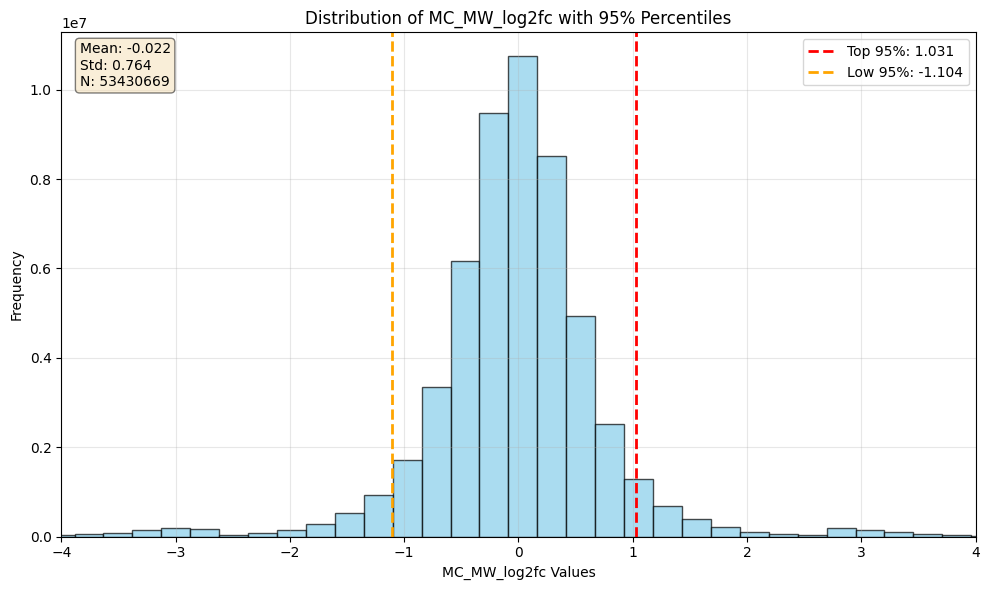

In [57]:
# 计算95%分位点
top_95 = df_regions['MC_MW_log2fc'].quantile(0.95)
low_95 = df_regions['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_regions['MC_MW_log2fc'].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-4, 4)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_regions['MC_MW_log2fc'].mean()
std_val = df_regions['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_regions)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [190]:
results=avg_results[avg_results.FDR <0.05]
results=full_results_filtered

In [33]:
results.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_TF_activity_summary_significant_avg_TFs.csv')

In [191]:
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])

/tmp/ipykernel_3807734/1019759776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])


In [192]:
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)


/tmp/ipykernel_3807734/3736920283.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)


In [193]:
results

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Region Subclass,log2FC,FDR,Subclass,Region,status,celltype.L2,absLog2FC,nlogp,Regulation
2521,metacluster_50.1homer__NDATGASTCAYN_Fos_None,metacluster_50.1#homer__NDATGASTCAYN_Fos,None,C_metacluster_50.1#transfac_public__M00038,46234,0.13832,9866,0.16497,12193,-0.48882,...,PFC_PFC_L4-5_IT_Glut,-0.48882,1.068120e-206,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.48882,-205.971380,-1
2689,metacluster_137.2homer__GGATGACTCATC_Fra2_None,metacluster_137.2#homer__GGATGACTCATC_Fra2,None,C_metacluster_50.1#transfac_public__M00038,46862,0.14100,10206,0.16699,12494,-0.46652,...,PFC_PFC_L4-5_IT_Glut,-0.46652,4.103690e-201,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.46652,-200.386825,-1
1554,metacluster_157.2dbtfbs__mm_FOSL1_C2C12_ENCSR0...,metacluster_157.2#dbtfbs__mm_FOSL1_C2C12_ENCSR...,None,C_metacluster_50.1#transfac_public__M00038,47909,0.13894,10265,0.16424,12530,-0.45869,...,PFC_PFC_L4-5_IT_Glut,-0.45869,7.784100e-203,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45869,-202.108792,-1
1559,metacluster_157.2homer__RATGASTCAT_JunB_None,metacluster_157.2#homer__RATGASTCAT_JunB,None,C_metacluster_50.1#transfac_public__M00038,45477,0.14093,9849,0.16635,12027,-0.45288,...,PFC_PFC_L4-5_IT_Glut,-0.45288,1.249460e-199,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45288,-198.903278,-1
2685,metacluster_137.2homer__ATGACTCATC_AP-1_None,metacluster_137.2#homer__ATGACTCATC_AP-1,None,C_metacluster_50.1#transfac_public__M00038,48755,0.14066,10542,0.16567,12876,-0.45049,...,PFC_PFC_L4-5_IT_Glut,-0.45049,5.300370e-198,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.45049,-197.275694,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1421,metacluster_24.2c2h2_zfs__M5280_None,metacluster_24.2#c2h2_zfs__M5280,None,C_metacluster_24.2#c2h2_zfs__M5280,99468,0.68294,24241,0.66356,24226,0.01453,...,HPF_HPF_Subiculum_SUB_Glut,0.01453,8.568930e-66,HPF_Subiculum_SUB_Glut,HPF,Up,HPF_Subiculum_SUB_Glut,0.01453,65.067073,1
3059,metacluster_6.2jaspar__MA0874.1_None,metacluster_6.2#jaspar__MA0874.1,None,C_metacluster_6.2#swissregulon__mm__Esx1,10440,0.16036,4668,0.16015,4782,0.01436,...,AMY_OPC,0.01436,9.752360e-32,OPC,AMY,Up,OPC,0.01436,31.010890,1
2455,metacluster_164.1swissregulon__mm__Meox1_None,metacluster_164.1#swissregulon__mm__Meox1,None,C_metacluster_164.1#swissregulon__mm__Meox1,12145,0.15987,5663,0.15987,5844,0.01432,...,AMY_OPC,0.01432,8.085400e-34,OPC,AMY,Up,OPC,0.01432,33.092298,1
1136,metacluster_163.1hocomoco__KLF5_MOUSE.H11MO.0....,metacluster_163.1#hocomoco__KLF5_MOUSE.H11MO.0.A,None,C_metacluster_3.7#kznf__SP1_HocoMoco.2_Misc,60800,1.41336,25226,1.47397,26730,0.01423,...,HPF_MFOL,0.01423,3.408150e-55,MFOL,HPF,Up,MFOL,0.01423,54.467481,1


In [194]:
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_3807734/2240312652.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation']=results['Regulation'].astype(float)


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


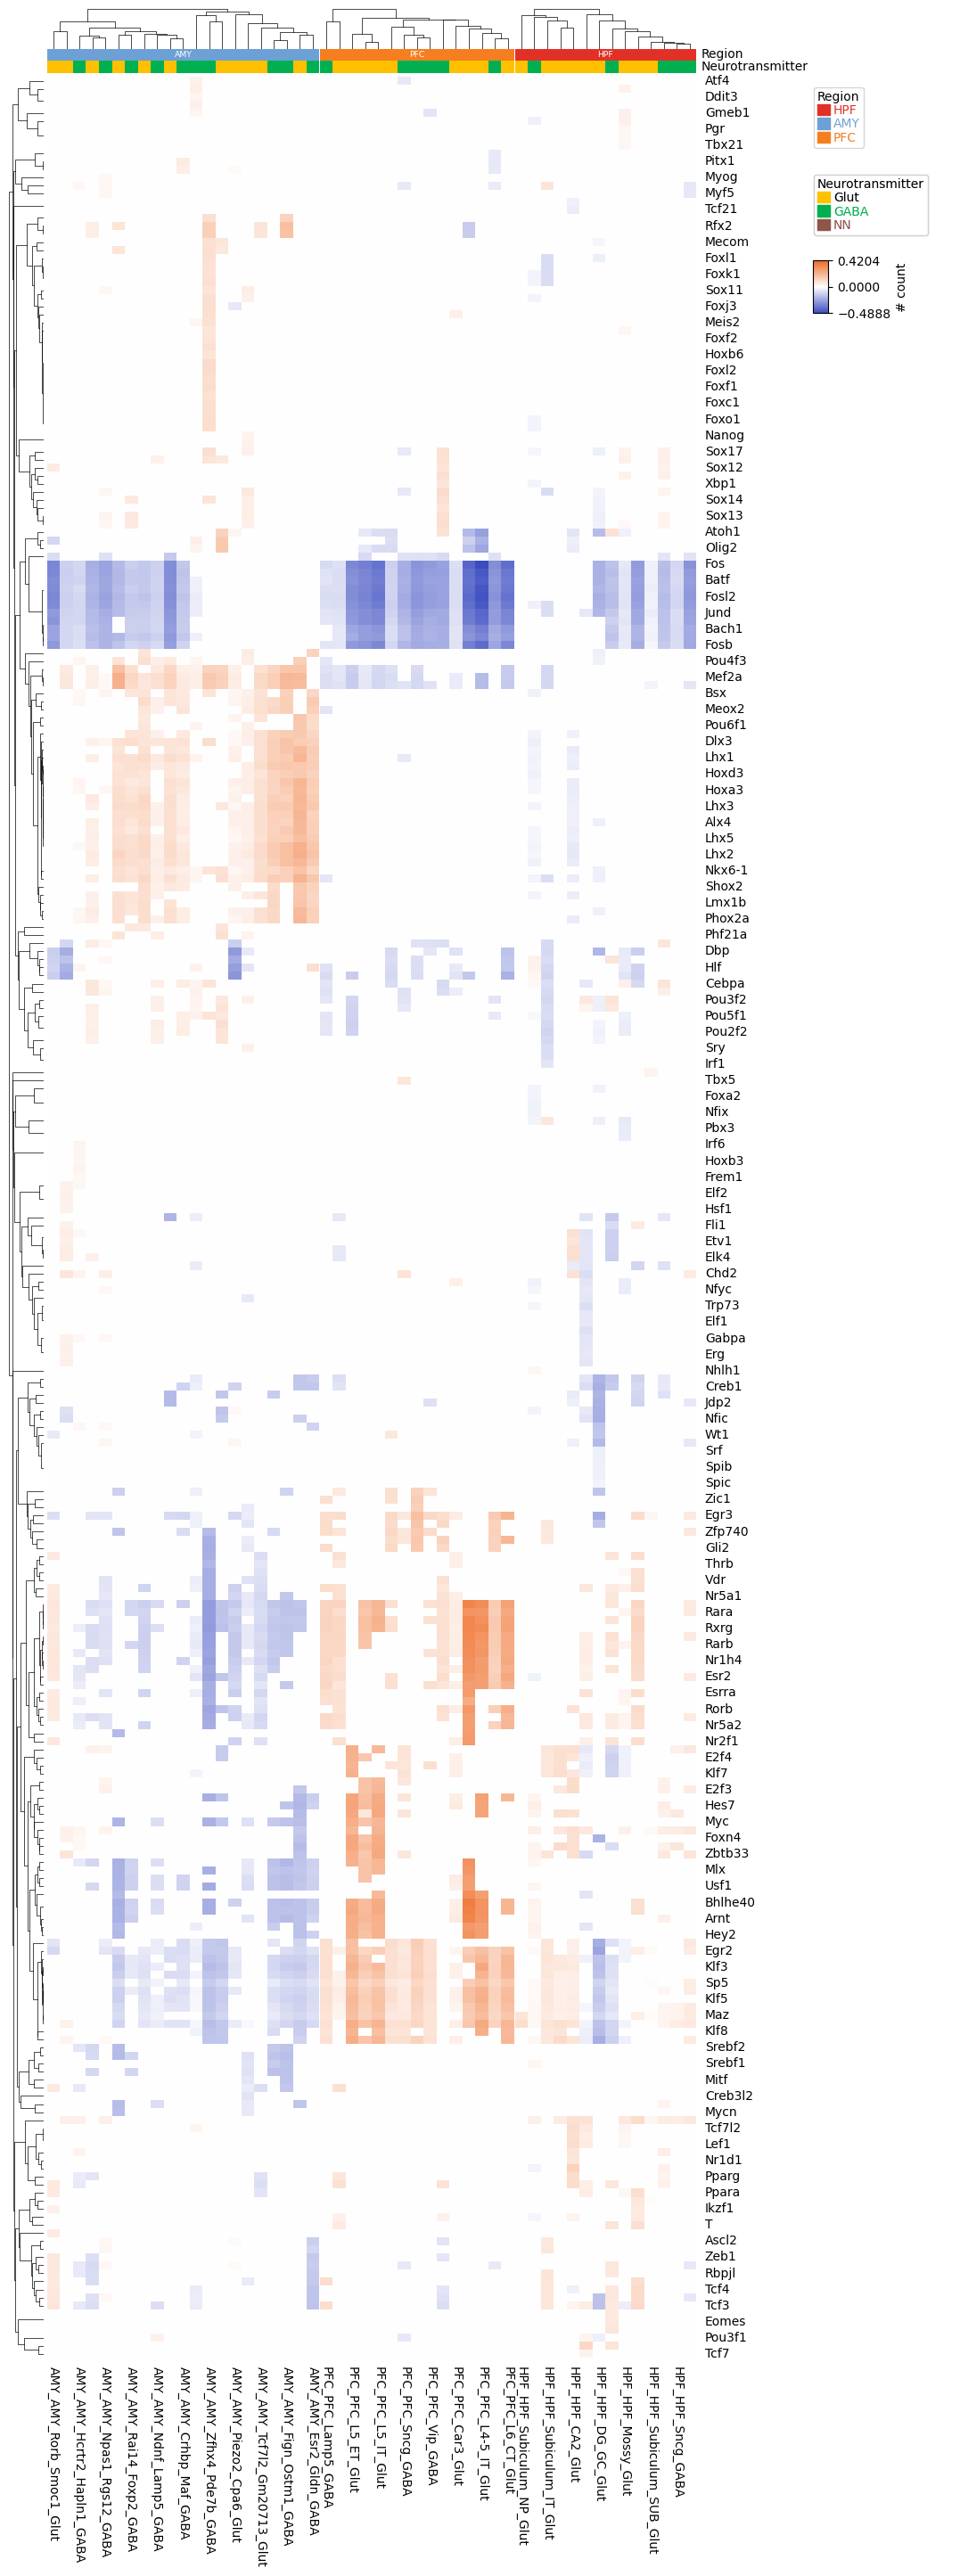

In [216]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PyComplexHeatmap as pch
from matplotlib.colors import LinearSegmentedColormap


# ---------------------------------------------------------
# 你的颜色
# ---------------------------------------------------------
region_colors = {
    "HPF": "#E13127",
    "AMY": "#6DA1D5",
    "PFC": "#F57E20",
}

nt_colors = {
    "Glut": "#FFC000",
    "GABA": "#00B050",
    "NN":   "#8c564b",
}


# ---------------------------------------------------------
# 主函数：绘制 TF × Region Subclass 热图
# ---------------------------------------------------------
def draw_tf_heatmap(df,value_col="Regulation", clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  

    if col_order is not None:
    # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]

    # Apply custom TF/row order if provided
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]

    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index="TF",
        columns="Region Subclass",
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)


    mat = df.pivot_table(
    index="TF",
    columns="Region Subclass",
    values=value_col,
    aggfunc="mean"
    )   

    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    # 1. Remove constant columns
    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]

    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )

    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )

    vmin = np.nanmin(mat.values)
    vmax = np.nanmax(mat.values)
    plt.figure(figsize=(10, 30))
    
    # print("Any NaN in columns? ", mat.isna().any())
    # print("Any inf? ", np.isinf(mat).any())

    # # 找出哪个 column 有 NaN / inf
    # print("Columns with NaN: ", mat.columns[mat.isna().any()].tolist())
    # print("Columns with inf: ", mat.columns[np.isinf(mat).any()].tolist())
    # ============================
    # 7. 绘制 Complex Heatmap
    # ============================
    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=True,
        col_cluster=True,
        row_dendrogram=True,
        col_dendrogram=True,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        # col_order=col_order,        # pass user-defined order
        # row_order=row_order,        # pass user-defined order
        # col_cluster=False if col_order is not None else True,
        # row_cluster=False if row_order is not None else True,

        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )

    # # # 调整字体
    # if cm.ax_col_names is not None:
    #     for txt in cm.ax_col_names.texts:
    #         txt.set_rotation(90)
    #         txt.set_fontsize(7)

    # for txt in cm.ax_heatmap.get_yticklabels():
    #     txt.set_fontsize(6)

    # # 调整列名字体
    # for txt in cm.ax_heatmap.get_xticklabels():
    #     txt.set_fontsize(7)
    #     txt.set_rotation(90)


    plt.show()
    return cm
cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC", clipping=30)

In [196]:
cm.dendrogram_row

In [197]:
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)

In [198]:
mat=cm.data2d.loc[row_names]

In [218]:
mat

Region Subclass,AMY_AMY_Cav1_Frmpd1_Glut,AMY_AMY_Zfhx4_Pde7b_GABA,AMY_AMY_Zfhx3_Glra1_Glut,AMY_AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Trabd2b_Coch_Glut,AMY_AMY_Tcf7l2_Gm20713_Glut,AMY_AMY_Rspo2_Gm11639_Glut,AMY_AMY_Rorb_Smoc1_Glut,AMY_AMY_Piezo2_Cpa6_Glut,AMY_AMY_Npas1_Rgs12_GABA,...,PFC_PFC_L6_IT_Glut,PFC_PFC_L5_IT_Glut,PFC_PFC_L5_NP_Glut,PFC_PFC_L5_ET_Glut,PFC_PFC_L4-5_IT_Glut,PFC_PFC_L2-3_IT_Glut,PFC_PFC_Car3_Glut,PFC_PFC_Sst_GABA,PFC_PFC_L6_CT_Glut,PFC_PFC_Vip_GABA
TF,,,,,,,,,,,,,,,,,,,,,
Atf4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
Mga,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
Ddit3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
Meis1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
Gmeb1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.07388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Eomes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
Tbx2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000
Pou3f1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000


In [199]:
denrow = cm.dendrogram_row

In [200]:
cm.dendrogram_row.dendrogram.keys()

dict_keys(['icoord', 'dcoord', 'ivl', 'leaves', 'color_list', 'leaves_color_list'])

In [201]:
n = len(cm.dendrogram_row.dendrogram["leaves"])
k = 10
labels = np.repeat(np.arange(k), n//k + 1)[:n]

In [ ]:
 focus=['Fos',
 'Junb',
 'Batf',
 'Fosl1',
 'Fosl2',
 'Jun',
 'Jund',
 'Atf3',
 'Bach1',
 'Bach2',
 'Fosb']

In [224]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated_focusTFs.csv', index=False)

In [220]:
focus

['Fos',
 'Junb',
 'Batf',
 'Fosl1',
 'Fosl2',
 'Jun',
 'Jund',
 'Atf3',
 'Bach1',
 'Bach2',
 'Fosb']

In [217]:
order = cm.dendrogram_row.dendrogram["leaves"]
tf_clusters = {cm.data2d.index[order[i]]: labels[i] for i in range(n)}

tf_clusters


{'Atf4': 0,
 'Mga': 0,
 'Ddit3': 0,
 'Meis1': 0,
 'Gmeb1': 0,
 'Irf5': 0,
 'Pgr': 0,
 'Ar': 0,
 'Tbx21': 0,
 'Mafb': 0,
 'Pitx1': 0,
 'Twist1': 0,
 'Myog': 0,
 'Bhlha15': 0,
 'Myf5': 0,
 'Msgn1': 0,
 'Tcf21': 0,
 'Rfx1': 0,
 'Rfx2': 0,
 'Rfx3': 0,
 'Mecom': 0,
 'Tbp': 0,
 'Foxl1': 0,
 'Foxl3': 0,
 'Foxk1': 0,
 'Foxo4': 0,
 'Sox11': 0,
 'Sox3': 0,
 'Foxj3': 0,
 'Foxp2': 1,
 'Meis2': 1,
 'Sox10': 1,
 'Foxf2': 1,
 'Foxd1': 1,
 'Hoxb6': 1,
 'Meis3': 1,
 'Foxl2': 1,
 'Foxp1': 1,
 'Foxf1': 1,
 'Rfx4': 1,
 'Foxc1': 1,
 'Foxj2': 1,
 'Foxo1': 1,
 'Foxo3': 1,
 'Nanog': 1,
 'Sox4': 1,
 'Sox17': 1,
 'Sox2': 1,
 'Sox12': 1,
 'Sox6': 1,
 'Xbp1': 1,
 'Sox5': 1,
 'Sox14': 1,
 'Sox8': 1,
 'Sox13': 1,
 'Sox9': 1,
 'Atoh1': 1,
 'Bhlhe22': 1,
 'Olig2': 2,
 'Mafk': 2,
 'Fos': 2,
 'Junb': 2,
 'Batf': 2,
 'Fosl1': 2,
 'Fosl2': 2,
 'Jun': 2,
 'Jund': 2,
 'Atf3': 2,
 'Bach1': 2,
 'Bach2': 2,
 'Fosb': 2,
 'Emx1': 2,
 'Pou4f3': 2,
 'Mef2c': 2,
 'Mef2a': 2,
 'Mef2d': 2,
 'Bsx': 2,
 'Lhx8': 2,
 'Meox2': 2,
 'Evx1'

In [204]:
denrow.linkage

array([[  2.        , 252.        ,   0.        ,   2.        ],
       [ 73.        ,  77.        ,   0.        ,   2.        ],
       [ 81.        ,  88.        ,   0.        ,   2.        ],
       ...,
       [168.        , 555.        ,   1.0007804 , 123.        ],
       [561.        , 562.        ,   1.00697486, 160.        ],
       [560.        , 563.        ,   1.10848198, 283.        ]])

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


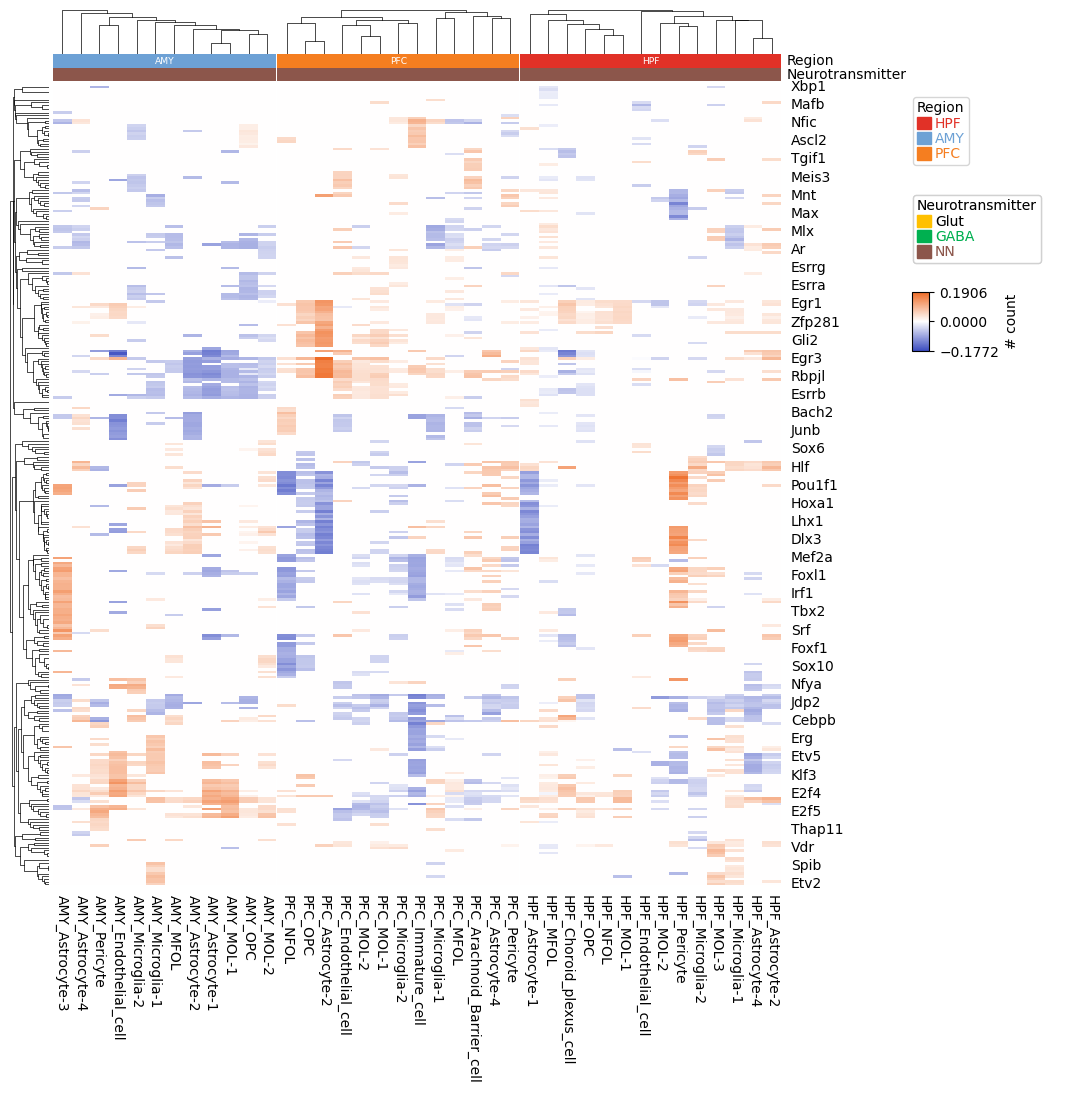

In [206]:
cmnn = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC")

In [207]:
df_all_filtered_CUSUS = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/scenicwil_tfs_fdr_log2fc0.csv')
df_3R = df_all_filtered_CUSUS[df_all_filtered_CUSUS['Region'].isin(['HPF','AMY','PFC'])]
df_3R['Region Subclass'] = df_3R['Region subclass']
df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
df_3R['Neurotransmitter'] = df_3R['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
df_3R['TF']= df_3R['TF'].str[:-3]

/tmp/ipykernel_3807734/2779743695.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['Region Subclass'] = df_3R['Region subclass']
/tmp/ipykernel_3807734/2779743695.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
/tmp/ipykernel_3807734/2779743695.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


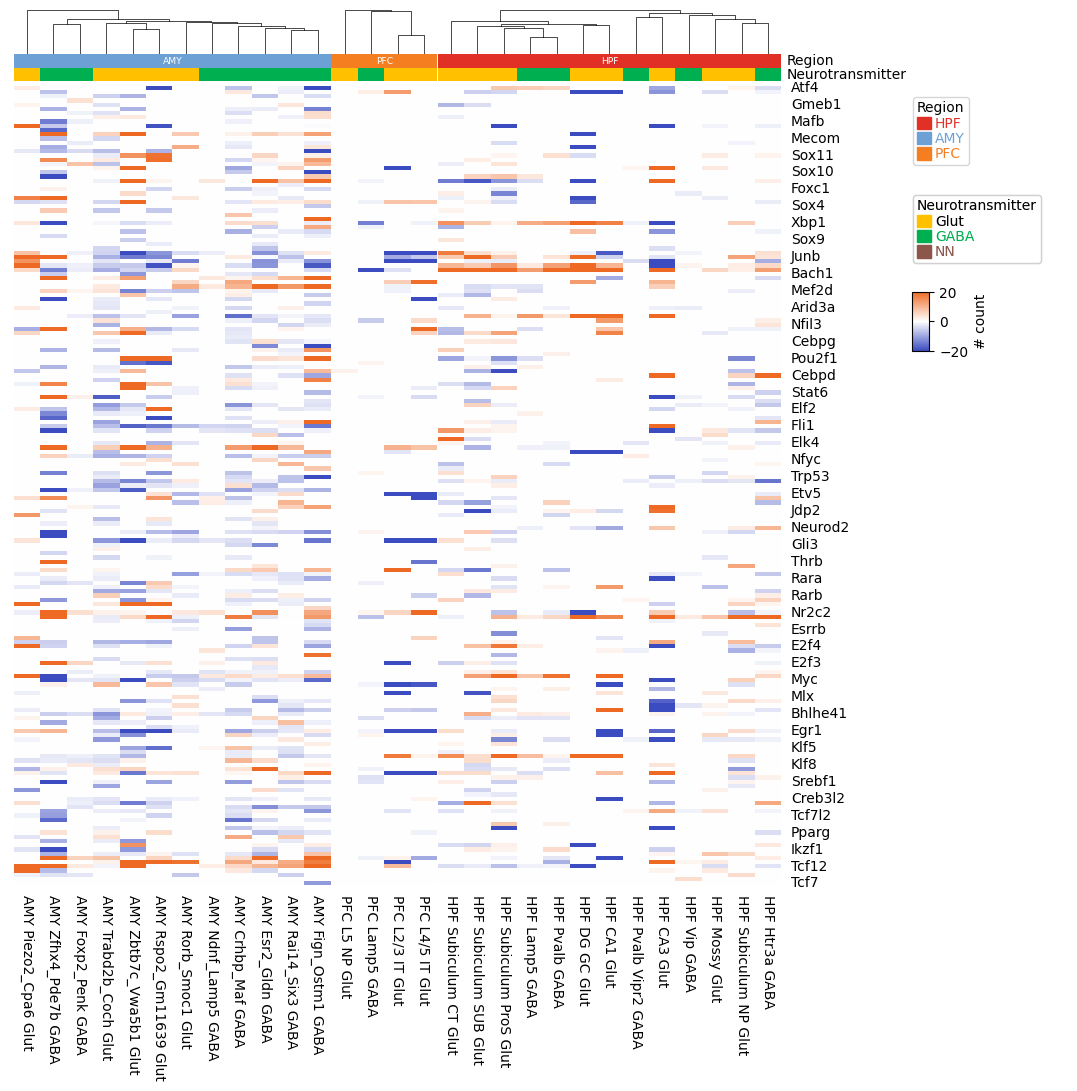

In [215]:
def draw_tf_heatmap_ordered(df,value_col="Regulation",row='TF',column='Region Subclass',
                            col_meta=['Region Subclass', 'Region', 'Neurotransmitter'],
                            clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  
    
    if row_order is not None:
        df = df[df[row].isin(row_order)]
    if col_order is not None:
        df = df[df[column].isin(col_order)]
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index=row,
        columns=column,
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()

    # order the mat if row_order and col_order are provided
    if col_order is not None:
        # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]
    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )
    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )
    plt.figure(figsize=(10, 10))

    row_cluster = True if row_order is None else False
    col_cluster = True if col_order is None else False
    row_dendrogram = True if row_order is None else False
    col_dendrogram = True if col_order is None else False

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_dendrogram=row_dendrogram,
        col_dendrogram=col_dendrogram,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )
    plt.show()
    return cm

cm2 = draw_tf_heatmap_ordered(df_3R[df_3R.Neurotransmitter!='NN'],row_order=row_names,value_col="nlogp", clipping=20)

In [209]:
df_3R

,TF,scores,log2FC,pval,FDR,pct_nz_group,pct_nz_reference,comparison,Subclass,Region,Sex,Neurotransmitter,Direction,Gene,Gene_name,Ensemble,Region subclass,Region Subclass,nlogp
5,Ets2,17.452005,0.623999,3.323606e-68,9.505513e-66,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Ets2(+),Ets2(+),Ets2(+),AMY MOL-2,AMY MOL-2,65.022024
6,Bmyc,13.413092,0.407593,5.068100e-41,2.415794e-39,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Bmyc(+),Bmyc(+),Bmyc(+),AMY MOL-2,AMY MOL-2,38.616940
7,Thra,10.567341,1.511824,4.222970e-26,1.097972e-24,0.665644,0.347495,CUSUS,MOL-2,AMY,F,NN,Up,Thra(+),Thra(+),Thra(+),AMY MOL-2,AMY MOL-2,23.959409
8,Klf10,10.401607,0.548061,2.437869e-25,5.810254e-24,0.996933,0.998911,CUSUS,MOL-2,AMY,F,NN,Up,Klf10(+),Klf10(+),Klf10(+),AMY MOL-2,AMY MOL-2,23.235805
9,Gtf2f1,9.123649,0.295695,7.263701e-20,1.598014e-18,1.000000,1.000000,CUSUS,MOL-2,AMY,F,NN,Up,Gtf2f1(+),Gtf2f1(+),Gtf2f1(+),AMY MOL-2,AMY MOL-2,17.796419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11018,Foxp1,-9.354158,-0.227279,8.426752e-21,2.131968e-19,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Foxp1(+),Foxp1(+),Foxp1(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-18.671219
11019,Arntl,-9.456558,-0.183556,3.182468e-21,8.946271e-20,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Arntl(+),Arntl(+),Arntl(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-19.048358
11020,Jdp2,-9.679680,-0.312057,3.678647e-22,1.329568e-20,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Jdp2(+),Jdp2(+),Jdp2(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-19.876289
11021,Zmiz1,-9.750012,-0.134844,1.844460e-22,7.777471e-21,1.000000,1.000000,CUSUS,HPF Subiculum SUB Glut,HPF,M,Glut,Down,Zmiz1(+),Zmiz1(+),Zmiz1(+),HPF Subiculum SUB Glut,HPF Subiculum SUB Glut,-20.109162


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


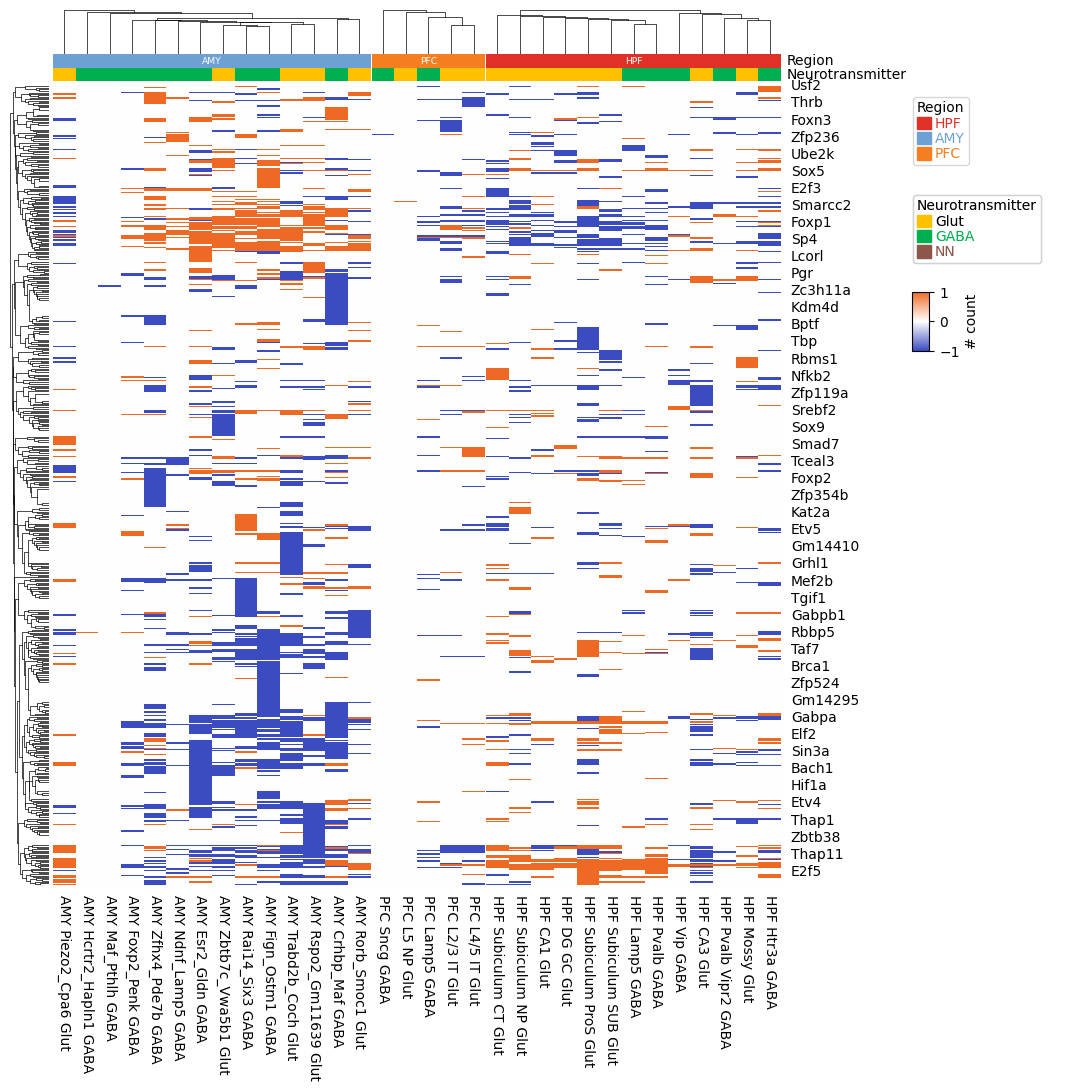

In [210]:
cm = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'], value_col="nlogp", clipping=1)

In [ ]:
df_tobias_drop = df_tobias.sort_values(by='abs_change',ascending=False).drop_duplicates(subset=['TFID'], keep='first')

In [ ]:
df_tobias_drop = df_tobias_drop[~df_tobias_drop['name'].str.contains('meta')]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = your TOBIAS BINDetect table
df_tobias_drop["neglog10_p"] = -np.log10(df_tobias_drop["MC_MW_pvalue"])

# ---- Top 20 UP (highest positive change) ----
top20_up = df_tobias_drop.nlargest(20, "MC_MW_change").copy()
top20_up["highlight"] = "up"

# ---- Top 20 DOWN (most negative change) ----
top20_down = df_tobias_drop.nsmallest(20, "MC_MW_change").copy()
top20_down["highlight"] = "down"

# ---- Combine top40 ----
top40 = pd.concat([top20_up, top20_down], axis=0)

# ---- Volcano plot ----
plt.figure(figsize=(10, 5))

# All background points (gray)
sns.scatterplot(
    data=df_tobias_drop,
    x="MC_MW_change",
    y="neglog10_p",
    color="lightgray",
    s=40
)

# Up 20 (red)
sns.scatterplot(
    data=top20_up,
    x="MC_MW_change",
    y="neglog10_p",
    color="red",
    s=80,
    edgecolor="black"
)

# Down 20 (blue)
sns.scatterplot(
    data=top20_down,
    x="MC_MW_change",
    y="neglog10_p",
    color="blue",
    s=80,
    edgecolor="black"
)

# ---- Add labels ----
for _, row in top40.iterrows():
    plt.text(
        row["MC_MW_change"],
        row["neglog10_p"],
        row["TF"],        # Your TF column name
        fontsize=8,
        ha="right",
        va="bottom"
    )

# ---- Axis + Style ----
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Motif accessibility change (MC_MW_change)", fontsize=14)
plt.ylabel("-log10(p-value)", fontsize=14)
plt.title("Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)", fontsize=16)
